# Global Shark Attacks Dataset:
## This is a table of shark attack incidents compiled by the Global Shark Attack File.
https://www.kaggle.com/datasets/alinedebenath/global-shark-attacks

In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

drive.mount('/content/drive')

dataset = pd.read_csv('/content/drive/MyDrive/Datasets/SAA/GSAF5.csv', header = 0, encoding="latin-1")
dataset.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Case Number,Date,Year,Type,Country,Area,Location,Activity,Name,Sex,...,Species,Investigator or Source,pdf,href formula,href,Case Number.1,Case Number.2,original order,Unnamed: 22,Unnamed: 23
0,2016.09.18.c,18-Sep-16,2016,Unprovoked,USA,Florida,"New Smyrna Beach, Volusia County",Surfing,male,M,...,NaN,"Orlando Sentinel, 9/19/2016",2016.09.18.c-NSB.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,2016.09.18.c,2016.09.18.c,5993,NaN,NaN
1,2016.09.18.b,18-Sep-16,2016,Unprovoked,USA,Florida,"New Smyrna Beach, Volusia County",Surfing,Chucky Luciano,M,...,NaN,"Orlando Sentinel, 9/19/2016",2016.09.18.b-Luciano.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,2016.09.18.b,2016.09.18.b,5992,NaN,NaN
2,2016.09.18.a,18-Sep-16,2016,Unprovoked,USA,Florida,"New Smyrna Beach, Volusia County",Surfing,male,M,...,NaN,"Orlando Sentinel, 9/19/2016",2016.09.18.a-NSB.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,2016.09.18.a,2016.09.18.a,5991,NaN,NaN
3,2016.09.17,17-Sep-16,2016,Unprovoked,AUSTRALIA,Victoria,Thirteenth Beach,Surfing,Rory Angiolella,M,...,NaN,"The Age, 9/18/2016",2016.09.17-Angiolella.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,2016.09.17,2016.09.17,5990,NaN,NaN
4,2016.09.15,16-Sep-16,2016,Unprovoked,AUSTRALIA,Victoria,Bells Beach,Surfing,male,M,...,2 m shark,"The Age, 9/16/2016",2016.09.16-BellsBeach.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,2016.09.16,2016.09.15,5989,NaN,NaN


# **Comprensión de los datos**

In [5]:
dataset.shape

(5992, 24)

In [6]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5992 entries, 0 to 5991
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Case Number             5992 non-null   object
 1   Date                    5992 non-null   object
 2   Year                    5992 non-null   int64 
 3   Type                    5992 non-null   object
 4   Country                 5949 non-null   object
 5   Area                    5590 non-null   object
 6   Location                5496 non-null   object
 7   Activity                5465 non-null   object
 8   Name                    5792 non-null   object
 9   Sex                     5425 non-null   object
 10  Age                     3311 non-null   object
 11  Injury                  5965 non-null   object
 12  Fatal (Y/N)             5973 non-null   object
 13  Time                    2779 non-null   object
 14  Species                 3058 non-null   object
 15  Inve

In [7]:
# Por de pronto vamos a eliminar atributos que a priori no nos van a servir
dataset = dataset.drop(["Name", "Investigator or Source", "pdf", "href formula", "href", "original order"], axis=1)

# PREGUNTA 1: Examen

1. Eliminación de atributos (Name, Source, PDF, etc.)

    ¿Por qué no se tienen en cuenta? Se eliminan porque son identificadores únicos o metadatos de referencia que no aportan valor predictivo estadístico directo en un modelo estándar.

        Name: Es un identificador (alta cardinalidad). Saber que la víctima se llama "John" no ayuda a predecir un ataque.

        PDF/Href: Son rutas de archivos, no características del ataque.

        Source: Es texto libre difícil de categorizar sin procesamiento previo.

    ¿Se podría sacar información? Sí, absolutamente. Con técnicas más avanzadas (Feature Engineering):

        Name: Se podría inferir el Género (si faltase en la columna Sex) o el origen étnico.

        Investigator or Source: Se podría analizar la fiabilidad del dato o extraer entidades (NER) para ver si ciertas fuentes reportan más fatalidades.

        PDF/Href: Contienen el año y ubicación en la URL, útiles para rellenar datos faltantes si las columnas principales estuvieran vacías.

In [8]:
# Vamos a visualizar las columnas con valores nulos
null_cols = dataset.isnull().sum()
null_cols[null_cols > 0]

,0
Country,43
Area,402
Location,496
Activity,527
Sex,567
Age,2681
Injury,27
Fatal (Y/N),19
Time,3213
Species,2934


<Axes: >

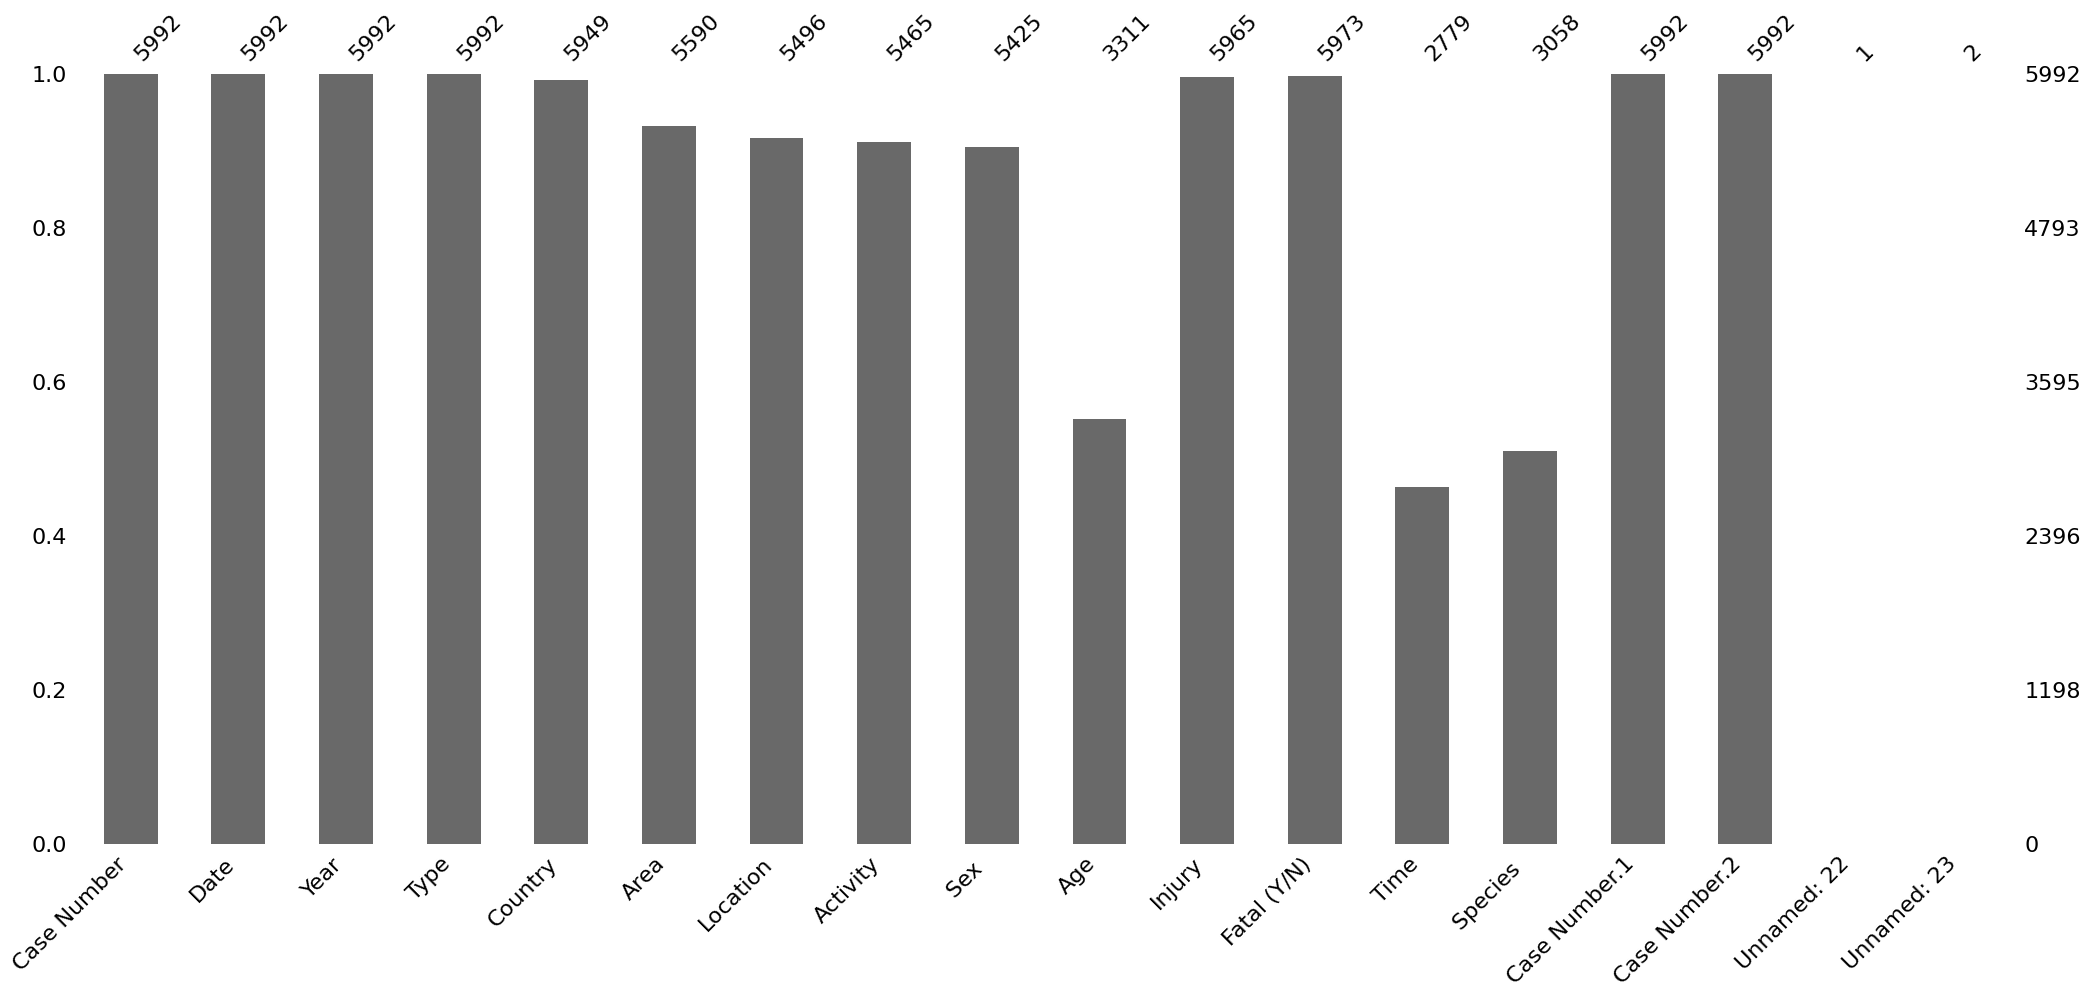

In [9]:
import missingno as msno

msno.bar(dataset)

In [10]:
# Podemos empezar viendo si hay duplicados
dataset.duplicated().sum()

np.int64(0)

# **Limpieza de datos**

## **Unnamed: 22 y Unnamed: 23**

In [11]:
# Directamente eliminamos los atributos por la gran cantidad de valores nulos que contiene
dataset = dataset.drop(["Unnamed: 22", "Unnamed: 23"], axis=1)


## **Time**

In [12]:
# ¿Cuántos valores nulos tiene?
nan_per=dataset['Time'].isna().sum()/len(dataset)*100
print (round(nan_per,2), ' % valores nulos')

53.62  % valores nulos


In [13]:
# Eliminamos el atributo
dataset = dataset.drop(["Time"], axis=1)

## **Case Number, Case Number.1 y Case Number.2"**

In [14]:
dataset['Case Number.1'].isin(dataset['Case Number']).value_counts()

,count
Case Number.1,
True,5980
False,12


In [15]:
dataset['Case Number.2'].isin(dataset['Case Number']).value_counts()

,count
Case Number.2,
True,5990
False,2


In [16]:
# Como básicamente contienen lo mismo nos quedmos con Case Number
dataset = dataset.drop(["Case Number.1", "Case Number.2"], axis=1)

## **Case Number y Date**

In [17]:
dataset["Date"]

,Date
0,18-Sep-16
1,18-Sep-16
2,18-Sep-16
3,17-Sep-16
4,16-Sep-16
...,...
5987,Before 1903
5988,Before 1903
5989,1900-1905
5990,1883-1889


In [18]:
# Muchos formatos diferentes, veremos que pasa con Case Number, que también contiene la fecha
# Podemos sacar el mes y el día, que el año ya lo tenemos, de Case Number
# Hay que tener en cuenta que cuando no se sabe la fecha aparece ND

dataset['Month']= dataset['Case Number'].apply(lambda x: x[5:7] if ((x[0:2]!='ND') & (x[0:2]!='nd') & (x[0:2]!='0.')) else 0)
dataset['Day']= dataset['Case Number'].apply(lambda x: x[8:10] if ((x[0:2]!='ND') & (x[0:2]!='nd') & (x[0:2]!='0.')) else 0)

dataset.Month = dataset.Month.astype('int64')
dataset.Day = dataset.Day.astype('int64')

In [19]:
dataset[['Case Number', 'Year', 'Month', 'Day']]

,Case Number,Year,Month,Day
0,2016.09.18.c,2016,9,18
1,2016.09.18.b,2016,9,18
2,2016.09.18.a,2016,9,18
3,2016.09.17,2016,9,17
4,2016.09.15,2016,9,15
...,...,...,...,...
5987,ND.0005,0,0,0
5988,ND.0004,0,0,0
5989,ND.0003,0,0,0
5990,ND.0002,0,0,0


# PREGUNTA 2: EXAMEN

2. Extracción de fecha desde “Case Number” vs “Date”

Mirando el archivo, la columna Date es muy "sucia" (texto libre). Contiene valores como "Reported 12-Jan-2000" o "Before 1903". En cambio, Case Number sigue un formato estricto: AAAA.MM.DD (ej. 2016.09.18.c).

    Razón: Es mucho más fácil y fiable programar una extracción de cadenas (slicing) sobre el formato estandarizado del Case Number que intentar parsear el texto irregular de Date

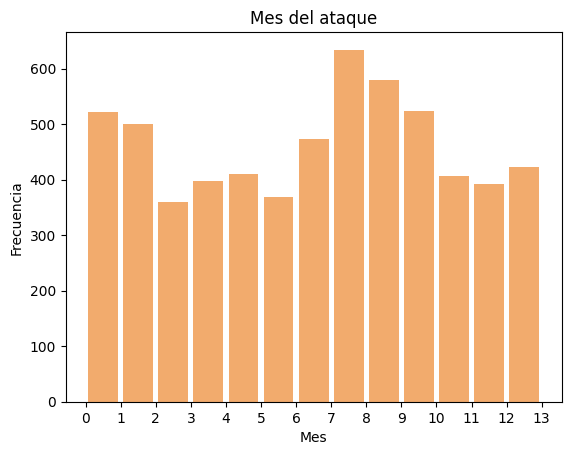

In [20]:
import matplotlib.pyplot as plot

intervalos = range(min(dataset.Month), max(dataset.Month) + 2) #calculamos los extremos de los intervalos

plot.hist(x=dataset.Month, bins=intervalos, color='#F2AB6D', rwidth=0.85)
plot.title('Mes del ataque')
plot.xlabel('Mes')
plot.ylabel('Frecuencia')
plot.xticks(intervalos)

plot.show()

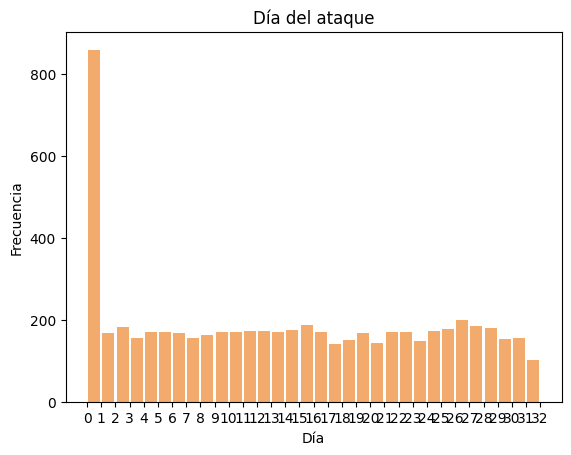

In [21]:
intervalos = range(min(dataset.Day), max(dataset.Day) + 2) #calculamos los extremos de los intervalos

plot.hist(x=dataset.Day, bins=intervalos, color='#F2AB6D', rwidth=0.85)
plot.title('Día del ataque')
plot.xlabel('Día')
plot.ylabel('Frecuencia')
plot.xticks(intervalos)

plot.show()

In [22]:
# Con lo que podemos eliminar Case Number y Date

dataset = dataset.drop(["Case Number", "Date"], axis=1)

In [23]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5992 entries, 0 to 5991
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Year         5992 non-null   int64 
 1   Type         5992 non-null   object
 2   Country      5949 non-null   object
 3   Area         5590 non-null   object
 4   Location     5496 non-null   object
 5   Activity     5465 non-null   object
 6   Sex          5425 non-null   object
 7   Age          3311 non-null   object
 8   Injury       5965 non-null   object
 9   Fatal (Y/N)  5973 non-null   object
 10  Species      3058 non-null   object
 11  Month        5992 non-null   int64 
 12  Day          5992 non-null   int64 
dtypes: int64(3), object(10)
memory usage: 608.7+ KB


## **Year**

In [24]:
dataset['Year'].value_counts()

,count
Year,
2015,139
2011,128
2014,125
0,124
2013,122
...,...
1555,1
1543,1
500,1


In [25]:
# Solo estudiaremos los casos producidos desde 1950, que son los más numerosos
dataset.loc[dataset['Year']>1950].Year.count()

np.int64(4228)

In [26]:
dataset = dataset[dataset['Year'] > 1950]

In [27]:
dataset.Year.max()

2016

In [28]:
# Vamos a agrupar
dataset['Decada'] = pd.cut(dataset.Year, bins = [1950, 1960, 1970, 1980, 1990, 2000, 2010, 2020], labels=range(1950,2020,10))

In [29]:
dataset['Decada'].value_counts()

,count
Decada,
2000,1024
2010,734
1990,627
1960,566
1950,513
1980,437
1970,327


In [30]:
dataset['Decada'] = dataset['Decada'].map({1950: 1, 1960: 2, 1970: 3, 1980: 4, 1990: 5, 2000: 6, 2010:7})

In [31]:
dataset['Decada'].value_counts()

,count
Decada,
6,1024
7,734
5,627
2,566
1,513
4,437
3,327


In [32]:
dataset = dataset.drop(["Year"], axis=1)

## **Type**

In [33]:
dataset['Type'].value_counts()

,count
Type,
Unprovoked,3163
Provoked,414
Invalid,349
Boat,194
Sea Disaster,93
Boating,15


In [34]:
dataset['Type'] = dataset['Type'].str.strip()
dataset['Type'] = dataset['Type'].str.replace('Boating','Boat')
dataset['Type'] = dataset['Type'].str.replace('Invalid','Unknown')
dataset['Type'].value_counts()

,count
Type,
Unprovoked,3163
Provoked,414
Unknown,349
Boat,209
Sea Disaster,93


In [35]:
dataset['Type'] = dataset['Type'].map({'Unprovoked': 1, 'Provoked': 2, 'Unknown': 3, 'Boat': 4, 'Sea Disaster': 5})
dataset['Type'].value_counts()

,count
Type,
1,3163
2,414
3,349
4,209
5,93


## **Country**

In [36]:
dataset['Country'].value_counts()

,count
Country,
USA,1771
AUSTRALIA,731
SOUTH AFRICA,450
PAPUA NEW GUINEA,110
BRAZIL,95
...,...
ARGENTINA,1
MARTINIQUE,1
INDIAN OCEAN,1


In [37]:
dataset['Country'].fillna('Unknown', inplace=True)
dataset['Country'] = dataset['Country'].str.strip().str.upper()
dataset['Country'].value_counts()

/tmp/ipython-input-3437202813.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['Country'].fillna('Unknown', inplace=True)


,count
Country,
USA,1771
AUSTRALIA,731
SOUTH AFRICA,450
PAPUA NEW GUINEA,110
BRAZIL,95
...,...
ARGENTINA,1
MARTINIQUE,1
INDIAN OCEAN,1


In [38]:
# Tenemos muchos países con solo una ocurrencia, los podemos agrupar
# dataset['Country'] = dataset['Country'].map(lambda x: 'OTHERS' if ((dataset['Country'] == x).sum() < 1) else x)
# dataset.loc[dataset['Country']=='UNKNOWN'] = 'OTHERS'

In [39]:
# Vamos a simplificar y solo consideraremos los casos de USA, que son los más numerosos
ds_USA = dataset[dataset['Country']=='USA']
ds_USA.groupby(['Country', 'Area']).count()

Type  Location  Activity  Sex   Age  Injury  \
Country Area                                                                  
USA     Alabama                   11        11        10    10    9      11   
        Alaska                     1         1         1     1    0       1   
        California               253       252       245   236  171     252   
        Connecticut                2         2         2     1    1       2   
        Delaware                   5         5         5     5    4       5   
        Florida                  909       902       861   878  768     906   
        Florida                    1         1         1     1    1       1   
        Georgia                    9         9         9     9    8       9   
        Guam                       1         1         1     1    1       1   
        Hawaii                   223       223       217   208  126     223   
        Illinois                   1         1         1     1    0       1   
        Johnston Atoll             1         0         1     1    1       1   
        Kentucky                   1         1         1     0    0       1   
        Louisiana                  8         7         8     7    5       8   
        Maine                      1         1         1     1    1       1   
        Maryland                   3         3         3     2    2       3   
        Massachusetts              7         7         7     6    6       7   
        Mississippi                3         3         3     3    3       3   
        Missouri                   1         1         1     1    1       1   
        New Jersey                12        12        11    12   10      12   
        New Mexico                 1         1         1     1    1       1   
        New York                   7         7         7     7    6       7   
        North & South Carolina     1         0         1     1    0       1   
        North Carolina            81        80        76    76   69      81   
        North Carolina             1         1         1     1    1       1   
        Oregon                    28        27        28    28   24      28   
        Palmyra Atoll              2         0         2     2    2       2   
        Pennsylvania               1         1         1     1    1       1   
        Puerto Rico               10         7         9     9    6      10   
        Rhode Island               2         1         2     1    1       2   
        South Carolina           110       107        94   106   84     109   
        South Carolina             1         1         1     1    1       1   
        Texas                     52        52        50    51   40      52   
        US Virgin Islands          4         4         4     4    3       4   
        Virginia                  14        14        14    14    8      14   
        Wake Island                1         1         1     1    0       1   
        Washington                 1         1         1     1    0       1   

                                Fatal (Y/N)  Species   Month  Day  Decada  
Country Area                                                               
USA     Alabama                          11         6     11   11      11  
        Alaska                            1         1      1    1       1  
        California                      253       211    253  253     253  
        Connecticut                       2         0      2    2       2  
        Delaware                          5         4      5    5       5  
        Florida                         909       496    909  909     909  
        Florida                           1         1      1    1       1  
        Georgia                           9         3      9    9       9  
        Guam                              1         1      1    1       1  
        Hawaii                          223       151    223  223     223  
        Illinois                      

In [40]:
ds_USA.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1771 entries, 0 to 4215
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   Type         1771 non-null   int64   
 1   Country      1771 non-null   object  
 2   Area         1770 non-null   object  
 3   Location     1748 non-null   object  
 4   Activity     1682 non-null   object  
 5   Sex          1690 non-null   object  
 6   Age          1365 non-null   object  
 7   Injury       1766 non-null   object  
 8   Fatal (Y/N)  1771 non-null   object  
 9   Species      1102 non-null   object  
 10  Month        1771 non-null   int64   
 11  Day          1771 non-null   int64   
 12  Decada       1771 non-null   category
dtypes: category(1), int64(3), object(9)
memory usage: 181.9+ KB


# PREGUNTA 3: EXAMEN

3. Inferencia de datos desconocidos (Día/Mes = 0)

El valor 0 indica un dato faltante (NaN). No podemos usar la media aritmética porque los meses/días son cíclicos o categóricos en este contexto.

    Algoritmo sugerido: K-Nearest Neighbors (KNN Imputer).

        Buscas los "K" ataques más parecidos en base a otras variables (mismo Country, Area y Activity similar). Asignas el mes/día más frecuente de esos vecinos al registro incompleto.

        Opción simple: Asignar la Moda (el mes donde más ataques ocurren en esa zona geográfica), aunque es menos preciso que KNN.

In [41]:
# Con lo que podemos eliminar el atributo
ds_USA = ds_USA.drop(["Country"], axis=1)

## **Area y Location**

In [42]:
ds_USA['Area'].isna().sum()

np.int64(1)

In [43]:
# Solo hay un nulo, lo eliminamos
ds_USA.drop(ds_USA[ds_USA['Area'].isna()].index, inplace = True)


# PREGUNTA 4: EXAMEN

4. Nulos en ds_USA[‘Area’]

    ¿Media, Mediana o Moda? La variable Area es categórica (texto, ej: "Florida", "California").

        Media/Mediana: No se pueden calcular con texto (matemáticamente imposible).

        Moda: Sí se podría haber usado. Es el valor más frecuente.

    Razonamiento: Si estamos en Country = USA, y la mayoría de ataques ocurren en el área "Florida", podríamos imputar los nulos con "Florida" (la moda). Sin embargo, eliminar el registro es más "seguro" para no introducir sesgo si hay pocos datos.

    Comando para rellenar con la moda:
    
    ds_USA['Area'].fillna(ds_USA['Area'].mode()[0], inplace=True)

In [44]:
ds_USA['Area']=ds_USA['Area'].astype('category').cat.codes

In [45]:
ds_USA['Area'].value_counts()

,count
Area,
5,909
2,253
9,223
30,110
23,81
32,52
25,28
34,14
19,12


In [46]:
ds_USA['Location'].value_counts()

,count
Location,
"New Smyrna Beach, Volusia County",157
"Daytona Beach, Volusia County",27
"Myrtle Beach, Horry County",17
"Ponce Inlet, Volusia County",17
"Melbourne Beach, Brevard County",15
...,...
"Zuma Beach, Santa Monica, Los Angeles County",1
East Moloka'i,1
"Pirates Beach, Galveston",1


In [47]:
# Eliminamos Location
ds_USA = ds_USA.drop(["Location"], axis=1)

## **Activity**

In [48]:
ds_USA['Activity'].value_counts()

,count
Activity,
Surfing,531
Swimming,212
Wading,96
Fishing,57
Standing,48
...,...
Body surfing & treading water,1
Bitten while cutting shark from net,1
Accidentally dragged overboard from the sampan Holokahana into school of yellowfin tuna,1


In [49]:
# Podríamos centrarnos en las actividades más frecuentes, pero por ahora lo vamos a dejar
ds_USA = ds_USA.drop(["Activity"], axis=1)

## **Sex**

In [50]:
# Tenemos que renombrar la columna
ds_USA.rename(columns={'Sex ': 'Sex'}, inplace=True)
ds_USA['Sex'].value_counts()

,count
Sex,
M,1399
F,288
M,1
lli,1


In [51]:
nan_per=ds_USA['Sex'].isna().sum()/len(dataset)*100
print (round(nan_per,2), ' % valores nulos')

1.92  % valores nulos


In [52]:
ds_USA['Sex'] = ds_USA['Sex'].str.strip()
ds_USA.drop(ds_USA[ds_USA['Sex']=='lli'].index, inplace = True)
ds_USA.drop(ds_USA[ds_USA['Sex'].isna()].index, inplace = True)
ds_USA['Sex'].value_counts()

,count
Sex,
M,1400
F,288


In [53]:
ds_USA['Sex'] = ds_USA['Sex'].map({'M': 1, 'F': 2})

## **Age**

In [54]:
ds_USA['Age'].value_counts()

,count
Age,
16,57
15,57
19,56
17,55
18,53
...,...
Ca. 33,1
75,1
21 or 26,1


In [55]:
ds_USA = ds_USA.drop(["Age"], axis=1)

## **Injury**

In [56]:
ds_USA['Injury'].value_counts()

,count
Injury,
Foot bitten,47
Left foot bitten,39
Right foot bitten,34
FATAL,25
No injury,23
...,...
Knee bitten after diver poked shark PROVOKED INCIDENT,1
"4"" laceration to left forearm",1
Lacerations & puncture wounds to left foot & buttocks,1


In [57]:
ds_USA = ds_USA.drop(["Injury"], axis=1)

## **Fatal (Y/N)**

In [58]:
# Sería la variable objetivo
dataset['Fatal (Y/N)'].value_counts()

,count
Fatal (Y/N),
N,3411
Y,751
UNKNOWN,50
N,8


In [59]:
# Podríamos añadir un nuevo valor: desconocido (unknown)
ds_USA['Fatal (Y/N)'] = ds_USA['Fatal (Y/N)'].str.strip()
ds_USA['Fatal (Y/N)'] = ds_USA['Fatal (Y/N)'].fillna('U')
ds_USA['Fatal (Y/N)'] = ds_USA['Fatal (Y/N)'].str.replace('n', 'N')
ds_USA['Fatal (Y/N)'] = ds_USA['Fatal (Y/N)'].str.replace('#VALUE!', 'U')
ds_USA['Fatal (Y/N)'] = ds_USA['Fatal (Y/N)'].str.replace('F', 'Y')
ds_USA['Fatal (Y/N)'] = ds_USA['Fatal (Y/N)'].str.replace('UNKNOWN', 'U')
ds_USA.rename(columns={'Fatal (Y/N)': 'Fatal (Y/N/U)'}, inplace=True)
ds_USA['Fatal (Y/N/U)'].value_counts()


,count
Fatal (Y/N/U),
N,1557
Y,120
U,11


In [60]:
ds_USA['Fatal (Y/N/U)'] = ds_USA['Fatal (Y/N/U)'].map({'N': 0, 'Y': 2, 'U':3})

## **Species**

In [61]:
ds_USA.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1688 entries, 0 to 4215
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Type           1688 non-null   int64   
 1   Area           1688 non-null   int8    
 2   Sex            1688 non-null   int64   
 3   Fatal (Y/N/U)  1688 non-null   int64   
 4   Species        1052 non-null   object  
 5   Month          1688 non-null   int64   
 6   Day            1688 non-null   int64   
 7   Decada         1688 non-null   category
dtypes: category(1), int64(5), int8(1), object(1)
memory usage: 96.0+ KB


In [62]:
nan_per=ds_USA['Species '].isna().sum()/len(dataset)*100
print (round(nan_per,2), ' % valores nulos')

15.04  % valores nulos


In [63]:
ds_USA.rename(columns={'Species ': 'Species'}, inplace=True)
ds_USA['Species'].fillna('Unknown', inplace=True)
ds_USA['Species'].value_counts()

/tmp/ipython-input-2519002319.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  ds_USA['Species'].fillna('Unknown', inplace=True)


,count
Species,
Unknown,637
Shark involvement not confirmed,44
4' shark,35
White shark,34
Tiger shark,21
...,...
small hammerhead shark,1
"18"" to 36"" shark",1
"Mr. Burgess of ISAF announced the injury was the bite of a 1.8 m [6'], 2- to 3-year old white shark. Subsequent investigation revealed there was no shark involvement in this incident",1


In [64]:
# Aunque puede ser una columna interesante en este supuesto no la vamos a considerar
# por la gran cantidad de nulos y valores desconocidos que contiene y por el formato tan diferente
ds_USA = ds_USA.drop(["Species"], axis=1)

In [65]:
ds_USA.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1688 entries, 0 to 4215
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Type           1688 non-null   int64   
 1   Area           1688 non-null   int8    
 2   Sex            1688 non-null   int64   
 3   Fatal (Y/N/U)  1688 non-null   int64   
 4   Month          1688 non-null   int64   
 5   Day            1688 non-null   int64   
 6   Decada         1688 non-null   category
dtypes: category(1), int64(5), int8(1)
memory usage: 82.8 KB


# PREGUNTA 5: EXAMEN

Sí, aparecen.

    Age: Es común encontrar errores de tecleo, edades imposibles (ej. negativos o >100 sin verificar) o formatos mixtos ("Teens", "Young").

    Year: En el dataset original hay años como "0" o años muy antiguos ("1500") que distorsionan el análisis temporal moderno.

    Time: A menudo contiene texto ("Afternoon") en lugar de hora militar, lo que se comporta como ruido u outlier si se espera un número.

In [66]:
def analizar_outliers(df, columna, umbral=1.5):
    """
    Detecta outliers usando el método del Rango Intercuartílico (IQR).

    Args:
        df (pd.DataFrame): El dataframe a analizar.
        columna (str): Nombre de la columna numérica.
        umbral (float): Multiplicador del IQR (estándar es 1.5).

    Returns:
        dict: Estadísticas y un DataFrame con los outliers encontrados.
    """
    # Verificar si la columna existe y es numérica
    if columna not in df.columns:
        return None

    # Eliminar nulos para el cálculo
    datos = df[columna].dropna()

    if datos.empty:
        return {"total_outliers": 0, "indices": []}

    # Cálculo de Cuartiles
    Q1 = datos.quantile(0.25)
    Q3 = datos.quantile(0.75)
    IQR = Q3 - Q1

    # Definir límites (Bigotes)
    limite_inferior = Q1 - (umbral * IQR)
    limite_superior = Q3 + (umbral * IQR)

    # Filtrar los outliers en el DF original
    outliers = df[(df[columna] < limite_inferior) | (df[columna] > limite_superior)]

    return {
        "columna": columna,
        "limite_inferior": limite_inferior,
        "limite_superior": limite_superior,
        "total_outliers": len(outliers),
        "porcentaje": (len(outliers) / len(df)) * 100,
        "data_outliers": outliers
    }

Columna: 'Year'
 - Límites aceptables: [1850.50, 2094.50]
 - Cantidad de Outliers: 238 (3.97%)
 - Ejemplo de valores atípicos encontrados:
   [1848 1850 1849 1847 1846 1845 1844 1842 1841 1840] ...
------------------------------


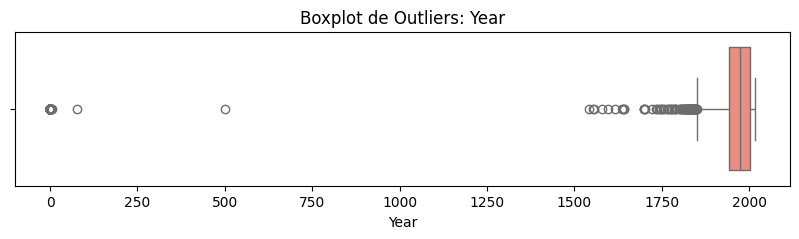

Columna: 'Age'
 - Límites aceptables: [-10.00, 62.00]
 - Cantidad de Outliers: 59 (0.98%)
 - Ejemplo de valores atípicos encontrados:
   [72. 64. 69. 65. 71. 68. 63. 70. 66. 77.] ...
------------------------------


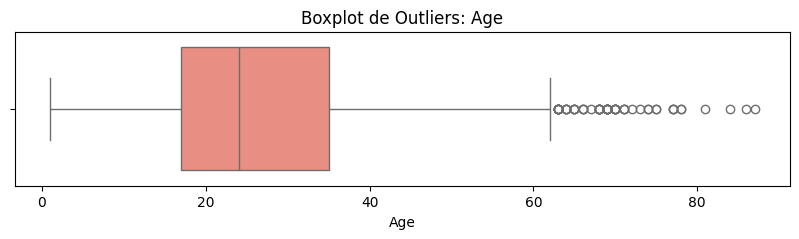

Columna: 'original order' - No se detectaron outliers significativos o la columna está vacía.



In [74]:
cols_a_analizar = ['Year', 'Age', 'original order']

for col in cols_a_analizar:
    if col in dataset.columns:
        # 'coerce' convierte errores (texto) en NaN automáticamente
        dataset[col] = pd.to_numeric(dataset[col], errors='coerce')

for col in cols_a_analizar:
    resultado = analizar_outliers(dataset, col)

    if resultado and resultado['total_outliers'] > 0:
        print(f"Columna: '{col}'")
        print(f" - Límites aceptables: [{resultado['limite_inferior']:.2f}, {resultado['limite_superior']:.2f}]")
        print(f" - Cantidad de Outliers: {resultado['total_outliers']} ({resultado['porcentaje']:.2f}%)")
        print(" - Ejemplo de valores atípicos encontrados:")
        # Mostrar los valores únicos de outliers encontrados para ver qué son
        print(f"   {resultado['data_outliers'][col].unique()[:10]} ...")
        print("-" * 30)

        # Visualización (Boxplot)
        plt.figure(figsize=(10, 2))
        sns.boxplot(x=dataset[col], color='salmon')
        plt.title(f'Boxplot de Outliers: {col}')
        plt.show()
    else:
        print(f"Columna: '{col}' - No se detectaron outliers significativos o la columna está vacía.\n")

# PREGUNTA 6: EXAMEN

6. Balanceo del Dataset

No, no está balanceado.

    Dependiendo de tu variable objetivo (Target), usualmente:

        Fatal (Y/N): La gran mayoría de ataques son "N" (No fatales). Hay muchos más heridos que fallecidos.

        Type: Predomina "Unprovoked".

    Esto implica que un modelo predictivo tenderá a decir siempre "No fatal" y acertará el 80-90% de las veces solo por probabilidad base, sin aprender patrones reales.

In [79]:
def comprobar_balance(df, target_col, umbral_alerta=70):
    """
    Analiza si una columna categórica está balanceada.

    Args:
        df (pd.DataFrame): El dataframe.
        target_col (str): Nombre de la columna objetivo (ej. 'Fatal (Y/N)').
        umbral_alerta (float): Porcentaje a partir del cual consideramos desbalanceo severo.
    """
    if target_col not in df.columns:
        print(f"Error: La columna '{target_col}' no existe.")
        return

    # Contar valores y porcentajes
    conteo = df[target_col].value_counts()
    porcentaje = df[target_col].value_counts(normalize=True) * 100

    # Crear un DataFrame resumen
    balance_df = pd.DataFrame({'Cantidad': conteo, 'Porcentaje (%)': porcentaje})

    print(f"--- Análisis de Balance: '{target_col}' ---")
    print(balance_df)
    print("\n")

    # Comprobación rápida de desbalanceo severo
    clase_dominante = porcentaje.idxmax()
    pct_dominante = porcentaje.max()

    if pct_dominante > umbral_alerta:
        print(f"ADVERTENCIA: Dataset DESBALANCEADO.")
        print(f"La clase '{clase_dominante}' domina con un {pct_dominante:.2f}%.")
        print("Modelos predictivos podrían sesgarse hacia esta clase.\n")
    else:
        print(f"El dataset parece razonablemente balanceado (Clase mayoritaria: {pct_dominante:.2f}%).\n")

    # Visualización
    plt.figure(figsize=(8, 4))
    sns.barplot(x=conteo.index, y=conteo.values, palette="viridis")
    plt.title(f'Distribución de clases en: {target_col}')
    plt.ylabel('Cantidad de registros')
    plt.xlabel('Clases')
    plt.show()

--- Análisis de Balance: 'Fatal (Y/N)' ---
             Cantidad  Porcentaje (%)
Fatal (Y/N)                          
N                4325       72.179573
Y                1552       25.901202
UNKNOWN            94        1.568758
NAN                19        0.317089
F                   1        0.016689
#VALUE!             1        0.016689


ADVERTENCIA: Dataset DESBALANCEADO.
La clase 'N' domina con un 72.18%.
Modelos predictivos podrían sesgarse hacia esta clase.



/tmp/ipython-input-266658171.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conteo.index, y=conteo.values, palette="viridis")


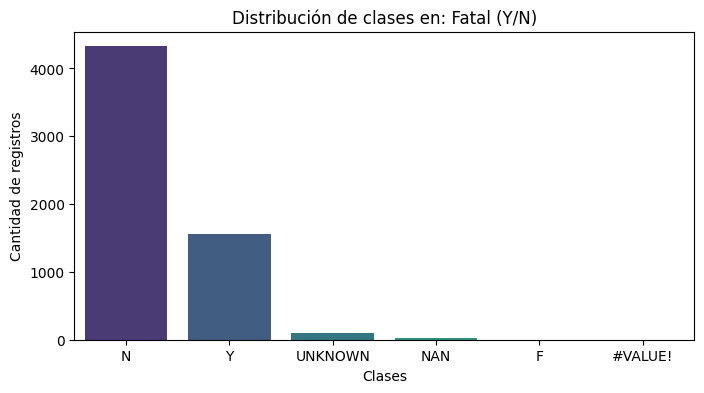

--- Análisis de Balance: 'Type' ---
              Cantidad  Porcentaje (%)
Type                                  
Unprovoked        4386       73.197597
Provoked           557        9.295728
Invalid            519        8.661549
Sea Disaster       220        3.671562
Boat               200        3.337784
Boating            110        1.835781


ADVERTENCIA: Dataset DESBALANCEADO.
La clase 'Unprovoked' domina con un 73.20%.
Modelos predictivos podrían sesgarse hacia esta clase.



/tmp/ipython-input-266658171.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conteo.index, y=conteo.values, palette="viridis")


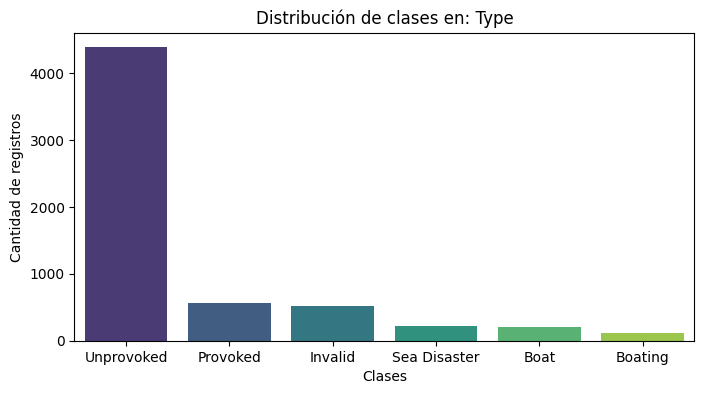

In [80]:
# Ejemplo 1: Analizar la columna 'Fatal (Y/N)' (Típico target binario)
# Primero hacemos una limpieza rápida porque esta columna suele estar sucia en GSAF
dataset['Fatal (Y/N)'] = dataset['Fatal (Y/N)'].astype(str).str.upper().str.strip()

# Ejecutamos la función
comprobar_balance(dataset, 'Fatal (Y/N)')

# Ejemplo 2: Analizar la columna 'Type' (Tipo de ataque)
comprobar_balance(dataset, 'Type')

#**Normalización 1**

In [ ]:
ds_USA.describe()

,Type,Area,Sex,Fatal (Y/N/U),Month,Day
count,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000
mean,1.299171,9.434242,1.170616,0.161730,7.009479,15.390995
std,0.723850,9.210465,0.376285,0.563064,2.737027,9.203487
min,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,1.000000,5.000000,1.000000,0.000000,5.000000,7.000000
50%,1.000000,5.000000,1.000000,0.000000,7.000000,15.500000
75%,1.000000,9.000000,1.000000,0.000000,9.000000,24.000000
max,5.000000,36.000000,2.000000,3.000000,12.000000,31.000000


In [ ]:
ds_USA.Decada = ds_USA.Decada.astype('int64')

In [ ]:
def normalize (horses):
  result = ds_USA.copy()

  for feature_name in ds_USA.columns:
    max_value = ds_USA[feature_name].max()
    min_value = ds_USA[feature_name].min()
    result[feature_name] = (ds_USA[feature_name] - min_value) / (max_value - min_value)
  return result

dataset_nor = normalize(dataset)
dataset_nor.describe()

,Type,Area,Sex,Fatal (Y/N/U),Month,Day,Decada
count,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000,1688.000000
mean,0.074793,0.262062,0.170616,0.053910,0.584123,0.496484,0.662520
std,0.180963,0.255846,0.376285,0.187688,0.228086,0.296887,0.300523
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.138889,0.000000,0.000000,0.416667,0.225806,0.500000
50%,0.000000,0.138889,0.000000,0.000000,0.583333,0.500000,0.833333
75%,0.000000,0.250000,0.000000,0.000000,0.750000,0.774194,0.833333
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


#**Normalización 2**

In [ ]:
from sklearn.preprocessing import StandardScaler

target = ds_USA['Fatal (Y/N/U)']
dataset_nor = ds_USA.drop(columns = ['Fatal (Y/N/U)'], axis = 1)
features = dataset_nor.columns
scaler = StandardScaler()
scaledTrain = scaler.fit_transform(dataset_nor)
dfTrain = pd.DataFrame(data=scaledTrain, columns=features)
dfTrain.head()

,Type,Area,Sex,Month,Day,Decada
0,-0.413427,-0.481578,-0.453557,0.727472,0.283564,1.123309
1,-0.413427,-0.481578,-0.453557,0.727472,0.283564,1.123309
2,-0.413427,-0.481578,-0.453557,0.727472,0.283564,1.123309
3,-0.413427,-0.481578,-0.453557,0.727472,-0.477243,1.123309
4,-0.413427,-0.047161,2.204793,0.727472,-0.911989,1.123309


# PREGUNTA 7: EXAMEN

7. En la práctica, ¿qué normalizaciones de datos aparecen?

Label Encoding: Para convertir variables categóricas ordinales o binarias (Sex: M/F -> 0/1).

Normalización Min-Max, que escala los valores al rango [0, 1].

Estandarización (Z-score) mediante StandardScaler, que centra los datos en media 0 y desviación típica 1.

#**Reducción de dimensionalidad**

##**Feature importance**

In [ ]:
import matplotlib.pyplot as plt
from sklearn.ensemble import ExtraTreesClassifier

# Feature_importances of tree based classifiers
X = ds_USA.drop("Fatal (Y/N/U)",1)    # Independent columns
y = ds_USA["Fatal (Y/N/U)"]           # Target feature
model = ExtraTreesClassifier()
model.fit(X,y)
print(model.feature_importances_) # Use inbuilt class

<ipython-input-67-3ac37b24e32f>:5: FutureWarning: In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only
  X = ds_USA.drop("Fatal (Y/N/U)",1)    # Independent columns


[0.13546754 0.19185811 0.02449298 0.21355688 0.30416233 0.13046216]


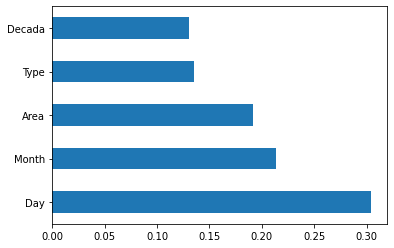

In [ ]:
# plot graph of feature importances for better visualization
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances.nlargest(5).plot(kind='barh')
plt.show()

##**Varianza**
Se calcula la varianza de cada una de las variables y se descantan aquellas que tengan una varianza baja en comparación con las otras variables de nuestro conjunto de datos, ya que las variables con una varianza baja no afectarán a la variable objetivo.

In [ ]:
ds_USA.var()

Type              0.523959
Area             84.832662
Sex               0.141590
Fatal (Y/N/U)     0.317041
Month             7.491315
Day              84.704175
Decada            3.251307
dtype: float64

# PREGUNTA 8: EXAMEN

Las grandes diferencias en las magnitudes de la varianza se deben a que las variables están medidas en escalas distintas y a la codificación numérica de variables categóricas.

La varianza no mide la relevancia de una variable respecto a la variable objetivo, sino únicamente su dispersión. Por ello, aplicar selección de características por varianza sin normalizar previamente puede llevar a eliminar variables importantes.

#**Correlation (Pearson)**

In [ ]:
import matplotlib.pyplot as plt

ds_USA.corr()

,Type,Area,Sex,Fatal (Y/N/U),Month,Day,Decada
Type,1.000000,0.023180,-0.043877,0.227358,-0.020581,-0.026645,-0.161878
Area,0.023180,1.000000,0.130148,0.025883,-0.035716,-0.000969,0.023530
Sex,-0.043877,0.130148,1.000000,-0.018404,-0.008478,0.012220,0.153908
Fatal (Y/N/U),0.227358,0.025883,-0.018404,1.000000,-0.040997,-0.011180,-0.187536
Month,-0.020581,-0.035716,-0.008478,-0.040997,1.000000,0.016937,0.074636
Day,-0.026645,-0.000969,0.012220,-0.011180,0.016937,1.000000,0.062524
Decada,-0.161878,0.023530,0.153908,-0.187536,0.074636,0.062524,1.000000


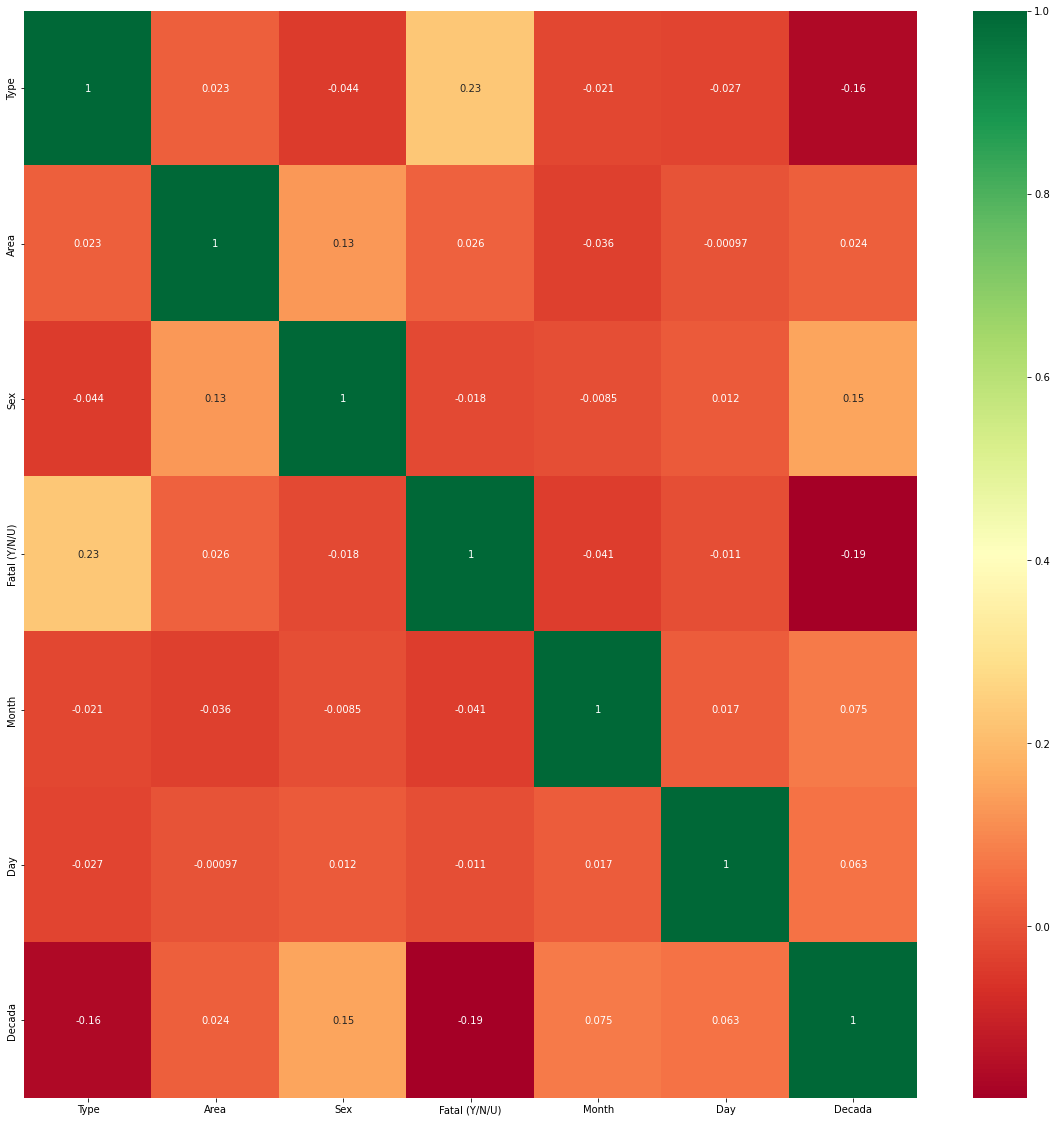

In [ ]:
plt.figure(figsize=(20,20))
g=sns.heatmap(ds_USA.corr(), annot=True, cmap="RdYlGn")

# PREGUNTA 9: EXAMEN

Al aplicar el método de selección por correlación, nos quedamos con los atributos Month, Type y Sex, ya que son los que presentan una mayor correlación en valor absoluto con la variable objetivo Fatal (Y/N/U).

El resto de variables muestran correlaciones muy bajas, cercanas a cero, por lo que su relación lineal con la variable objetivo es débil y su aportación al modelo sería limitada.

#**Backward elimination**

In [ ]:
import statsmodels.api as sm

X = ds_USA
y = ds_USA["Fatal (Y/N/U)"]
ds_USA.head()

,Type,Area,Sex,Fatal (Y/N/U),Month,Day,Decada
0,1,5,1,0,9,18,7
1,1,5,1,0,9,18,7
2,1,5,1,0,9,18,7
6,1,5,1,0,9,11,7
7,1,9,2,0,9,7,7


In [ ]:
cols = list(X.columns)
pmax = 1
while (len(cols)>0):
    p= []
    X_1 = X[cols]
    X_1 = sm.add_constant(X_1)
    model = sm.OLS(y,X_1).fit()
    p = pd.Series(model.pvalues.values[1:],index = cols)
    pmax = max(p)
    feature_with_p_max = p.idxmax()
    if(pmax>0.05):
        cols.remove(feature_with_p_max)
    else:
        break
selected_features_BE = cols
print(selected_features_BE)

['Type', 'Area', 'Fatal (Y/N/U)', 'Month', 'Day', 'Decada']


/usr/local/lib/python3.8/dist-packages/statsmodels/tsa/tsatools.py:142: FutureWarning: In a future version of pandas all arguments of concat except for the argument 'objs' will be keyword-only
  x = pd.concat(x[::order], 1)
/usr/local/lib/python3.8/dist-packages/statsmodels/tsa/tsatools.py:142: FutureWarning: In a future version of pandas all arguments of concat except for the argument 'objs' will be keyword-only
  x = pd.concat(x[::order], 1)


# PREGUNTA 10: EXAMEN

Sí, existe un error en el código de Backward Elimination. La variable objetivo Fatal (Y/N/U) se incluye incorrectamente dentro del conjunto de variables independientes X, lo que provoca que el modelo utilice la variable objetivo como predictor de sí misma, invalidando el proceso de selección.

Además, se utiliza una regresión lineal (OLS) cuando la variable dependiente es categórica, lo que no es adecuado desde el punto de vista estadístico.

📌 ¿Dónde está el error?

*   X = ds_USA
*   y = ds_USA["Fatal (Y/N/U)"]

✔️ Corrección correcta:
* X = ds_USA.drop(columns=["Fatal (Y/N/U)"])
* y = ds_USA["Fatal (Y/N/U)"]

# PREGUNTA 11: EXAMEN

11. Discretización y One Hot Encoding

    Discretización (Binning): Convertir una variable continua en intervalos (categorías).

        Ejemplo: Columna Age. En lugar de usar 12, 14, 50, creamos grupos: "Niño" (0-14), "Adulto" (15-60), "Anciano" (>60).

    One Hot Encoding: Convertir una variable categórica en múltiples columnas binarias (0 o 1).

        Ejemplo: Columna Sex con valores "M", "F".

        Se crean dos columnas nuevas: Sex_M y Sex_F. Si es hombre, Sex_M=1 y Sex_F=0.

#**PCA 1**

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [ ]:
# Normalizamos los datos
scaler=StandardScaler()
df = ds_USA.drop(['Fatal (Y/N/U)'], axis=1)     # quito la variable dependiente "Y"
scaler.fit(df)
X_scaled=scaler.transform(df)                   # Ahora si, escalo los datos y los normalizo

In [ ]:
# Instanciamos PCA
pca=PCA(n_components=6)
pca.fit(X_scaled)             # obtener los componentes principales
X_pca=pca.transform(X_scaled) # convertimos nuestros datos con las nuevas dimensiones de PCA

In [ ]:
print("shape of X_pca", X_pca.shape)
expl = pca.explained_variance_ratio_
print(expl)
print('suma:',sum(expl[0:14]))

shape of X_pca (1688, 6)
[0.21463175 0.18547428 0.16404353 0.16246269 0.14353039 0.12985736]
suma: 1.0


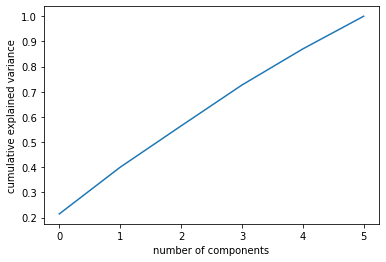

In [ ]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance')
plt.show()

#**PCA 2**

In [ ]:
ds_USA.keys()

Index(['Type', 'Area', 'Sex', 'Fatal (Y/N/U)', 'Month', 'Day', 'Decada'], dtype='object')

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
df = ds_USA.drop(['Fatal (Y/N/U)'], axis=1) # quito la variable dependiente "Y"
scaler.fit(df)
scaled_data=scaler.transform(df)
scaled_data


array([[-0.41342712, -0.48157784, -0.45355737,  0.72747234,  0.28356403,
         1.12330917],
       [-0.41342712, -0.48157784, -0.45355737,  0.72747234,  0.28356403,
         1.12330917],
       [-0.41342712, -0.48157784, -0.45355737,  0.72747234,  0.28356403,
         1.12330917],
       ...,
       [-0.41342712, -0.48157784, -0.45355737, -2.56174189, -1.67279598,
        -2.20520905],
       [-0.41342712, -0.80739082, -0.45355737, -0.00346415,  0.3922507 ,
        -2.20520905],
       [-0.41342712, -0.04716053, -0.45355737, -0.3689324 ,  1.0443707 ,
        -2.20520905]])

In [ ]:
from sklearn.decomposition import PCA

pca=PCA(n_components=2)
pca.fit(scaled_data)
x_pca=pca.transform(scaled_data)

Text(0, 0.5, 'Second principle component')

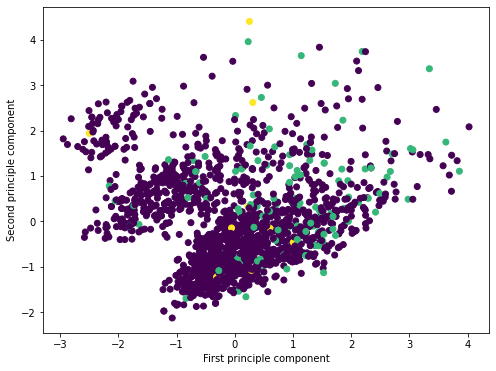

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(x_pca[:,0],x_pca[:,1],c=ds_USA['Fatal (Y/N/U)'])
plt.xlabel('First principle component')
plt.ylabel('Second principle component')

# PREGUNTA 12: EXAMEN

La diferencia entre PCA1 y PCA2 es que PCA1 se utiliza para analizar la varianza explicada y decidir cuántos componentes principales conservar, mientras que PCA2 se emplea para visualizar los datos en dos dimensiones y observar la posible separación entre clases.

En PCA no se seleccionan variables originales, sino componentes principales. Por tanto, nos quedaríamos con los primeros componentes que expliquen la mayor parte de la varianza (por ejemplo, PC1 y PC2 en PCA2, o los primeros 2–3 componentes en PCA1).